In [11]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

In [12]:
pl.Config.set_tbl_rows(2)
sns.set_theme(palette="deep", style="whitegrid")

In [13]:
df = (
    pl.scan_csv("anime_full.csv")
    .collect()
)

In [14]:
df.head()

anime_id,name,score,genres,english_name,type,episodes,aired,premiered,producers,licensors,studios,source,duration,rating_x,ranked,popularity,members,favorites,watching,completed,on_hold,dropped,plan_to_watch,score_10,score_9,score_8,score_7,score_6,score_5,score_4,score_3,score_2,score_1,user_id,rating_y,watching_status,watched_episodes
f64,str,f64,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,"""Cowboy Bebop""",8.78,"""Action, Adventure, Comedy, Dra…","""Cowboy Bebop""","""TV""",26.0,"""Apr 3, 1998 to Apr 24, 1999""","""Spring 1998""","""Bandai Visual""","""Funimation, Bandai Entertainme…","""Sunrise""","""Original""","""24 min. per ep.""","""R - 17+ (violence & profanity)""",28.0,39.0,1.25196e6,61971.0,105808.0,718161.0,71513.0,26678.0,329800.0,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,20764.0,8.0,2.0,26.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.0,"""Cowboy Bebop""",8.78,"""Action, Adventure, Comedy, Dra…","""Cowboy Bebop""","""TV""",26.0,"""Apr 3, 1998 to Apr 24, 1999""","""Spring 1998""","""Bandai Visual""","""Funimation, Bandai Entertainme…","""Sunrise""","""Original""","""24 min. per ep.""","""R - 17+ (violence & profanity)""",28.0,39.0,1.25196e6,61971.0,105808.0,718161.0,71513.0,26678.0,329800.0,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,34395.0,0.0,6.0,0.0


In [15]:
df.dtypes

[Float64,
 String,
 Float64,
 String,
 String,
 String,
 Float64,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64]

In [16]:
numeric_analysis_cols = [
    'score',
    'episodes',
    'members',
    'favorites',
    'watching',
    'completed',
    'on_hold',
    'dropped',
    'plan_to_watch'
]

categorical_analysis_cols = [
    'type',
    'source',
    'rating_x'
]

In [17]:
df_log = df.with_columns(
    [
        pl.col(col).log1p().alias(col)
        for col, dtype in df.schema.items()
        if dtype.is_numeric()
    ]
)

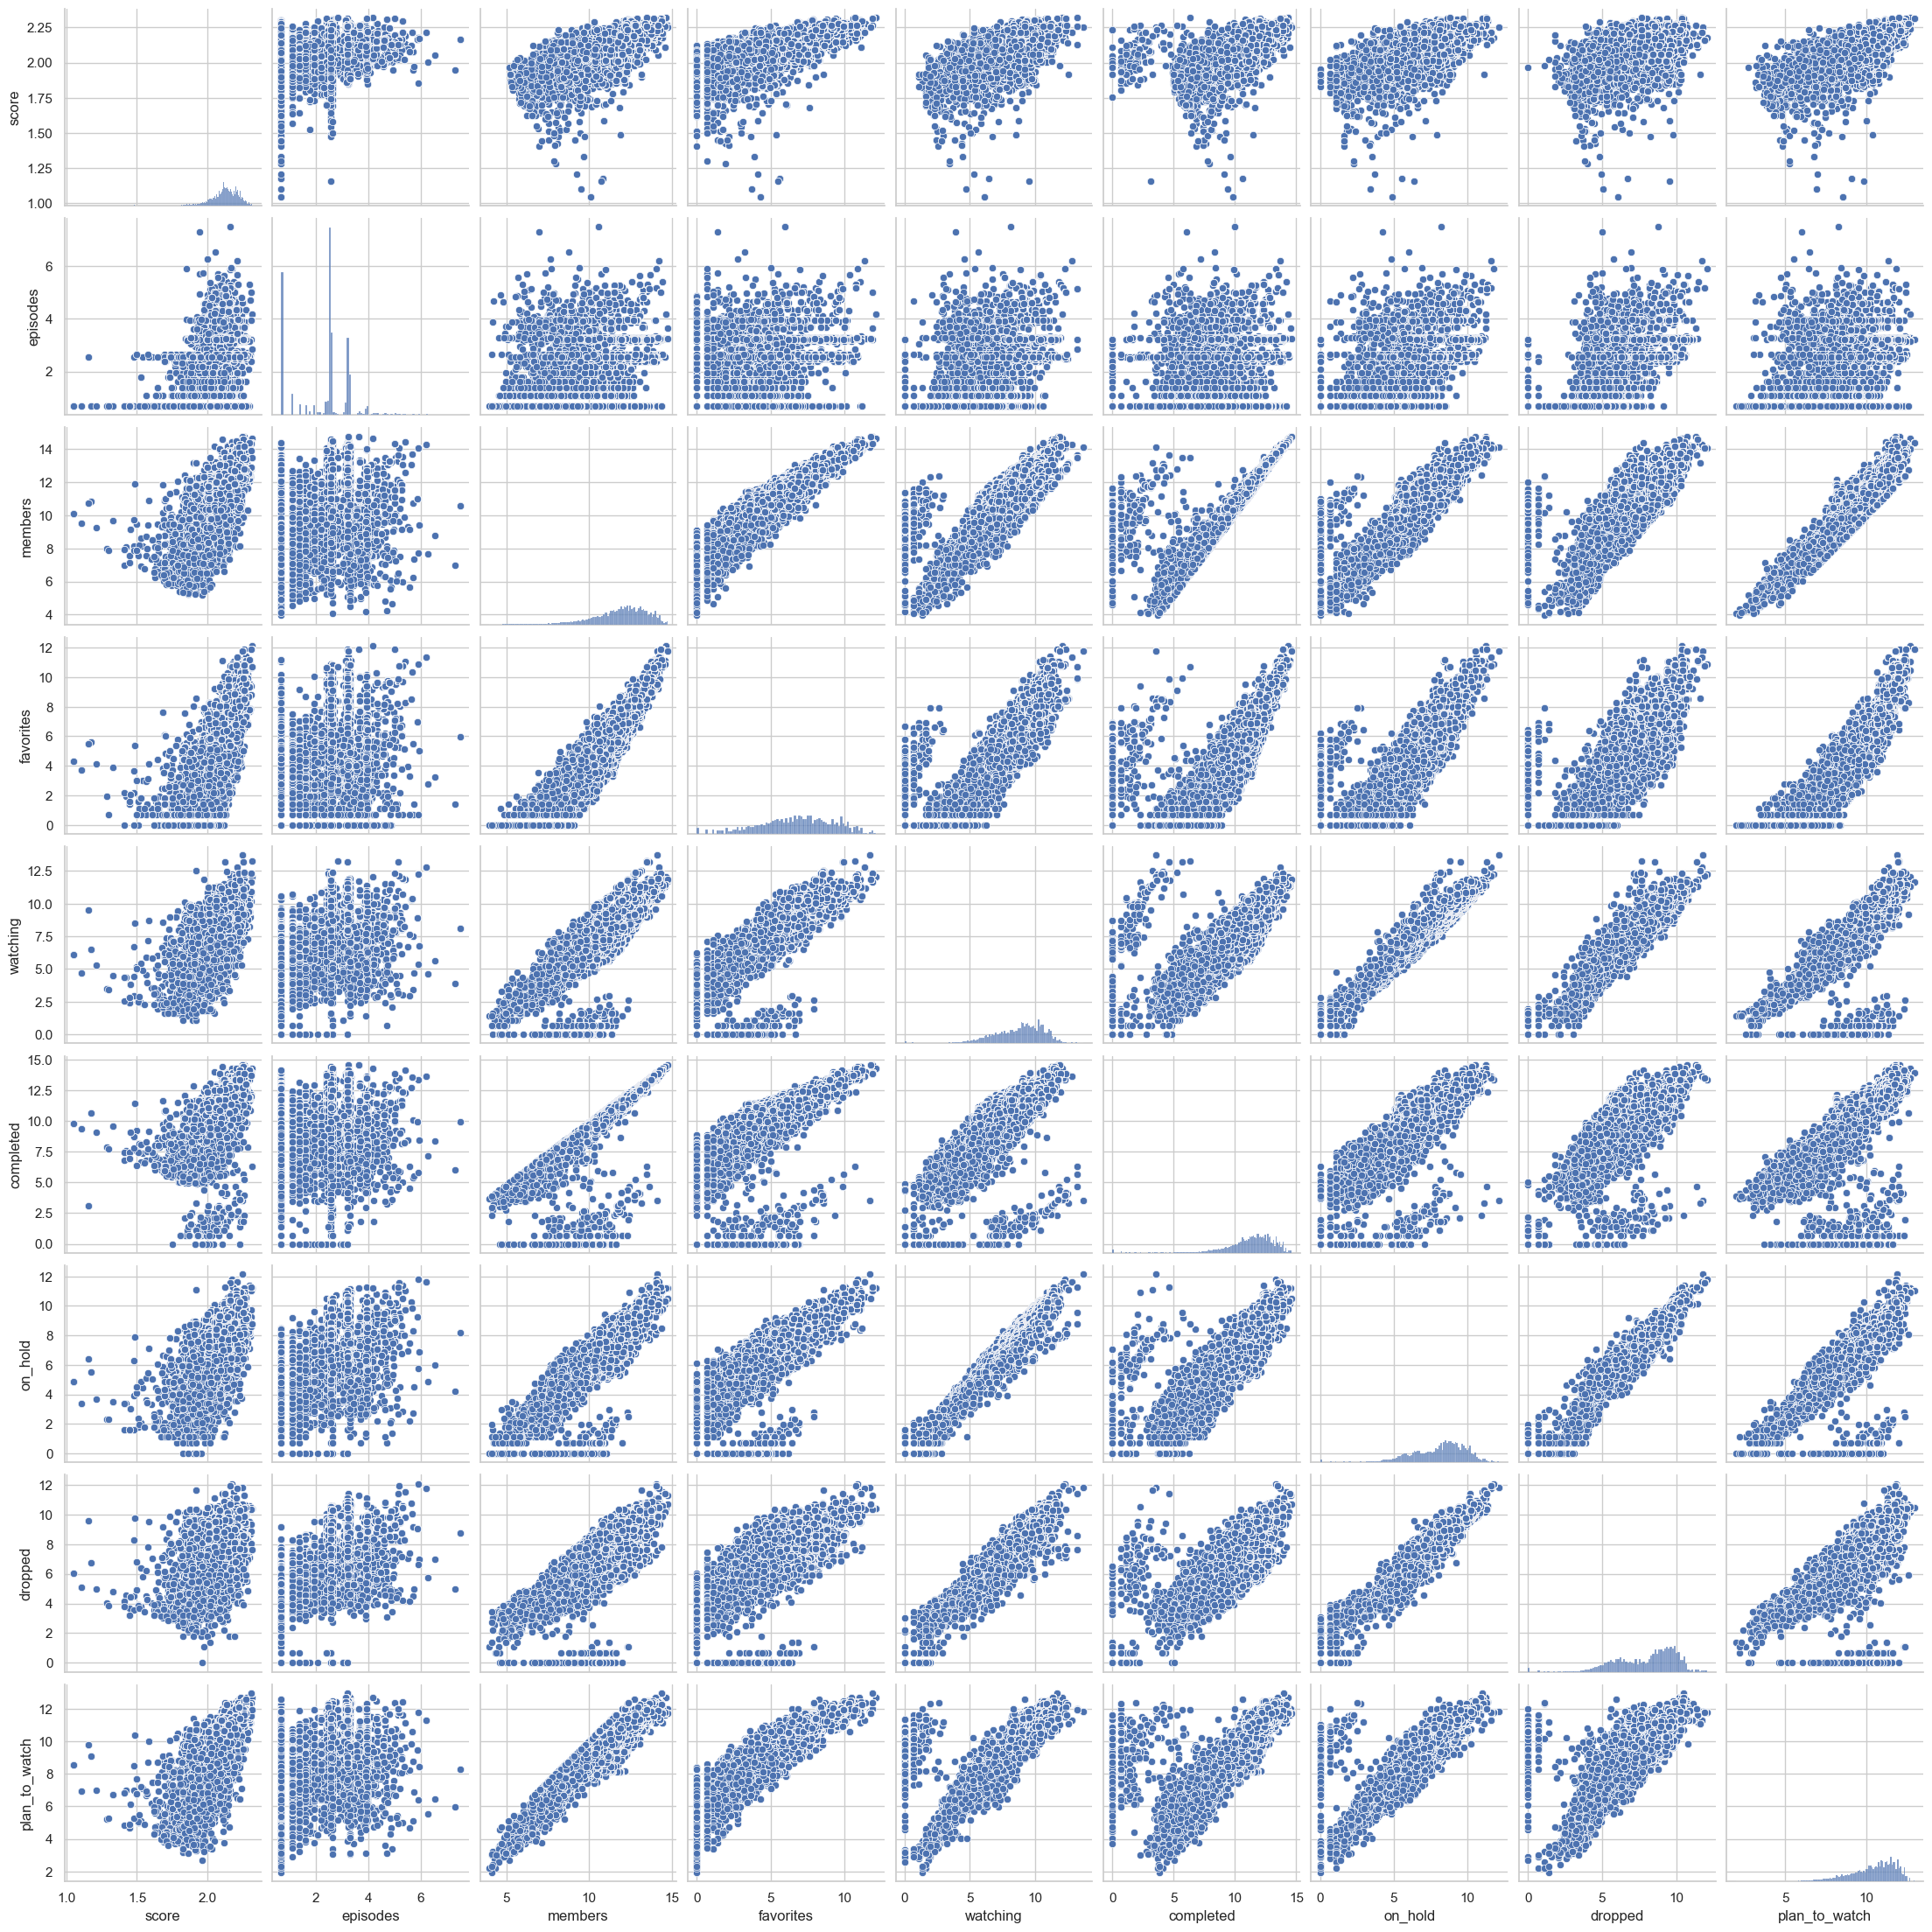

In [18]:
sns.pairplot(
    df_log.to_pandas(),
    vars=numeric_analysis_cols
)

plt.show()

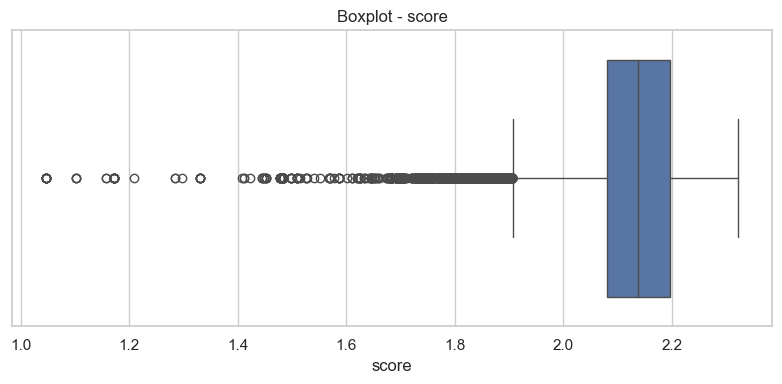

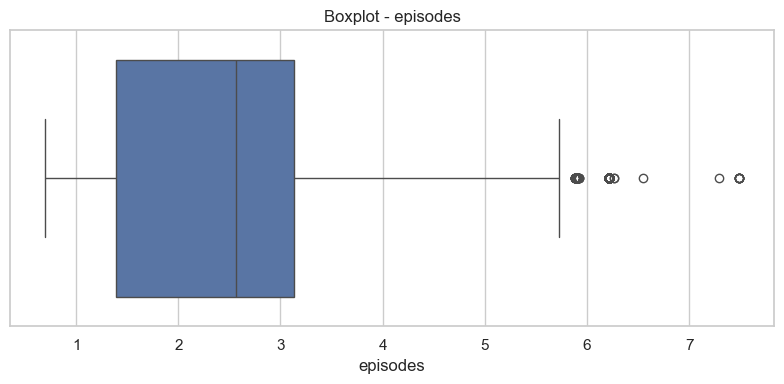

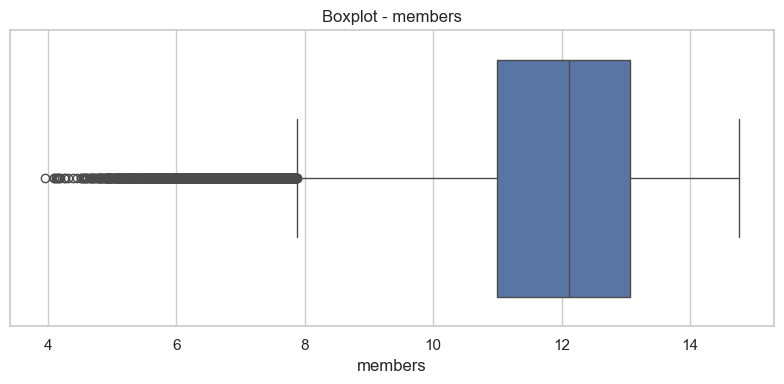

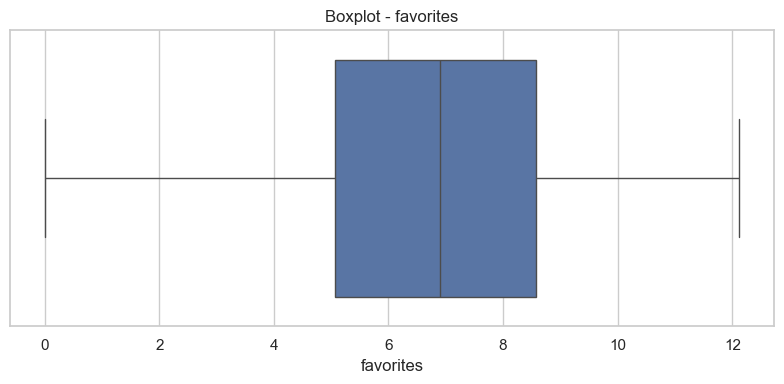

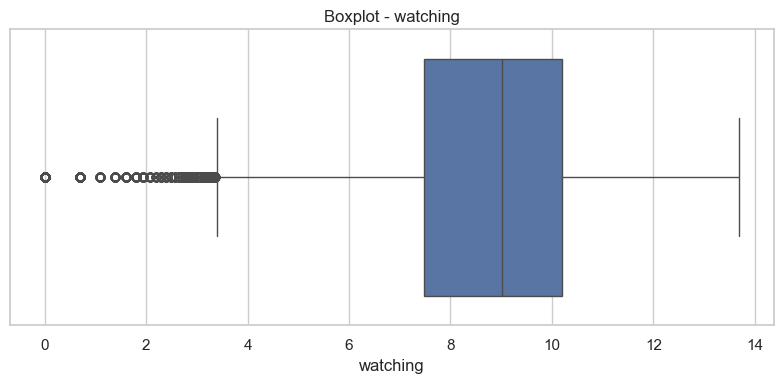

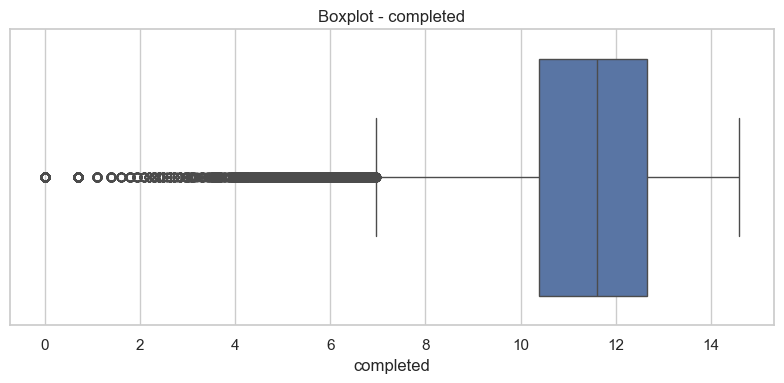

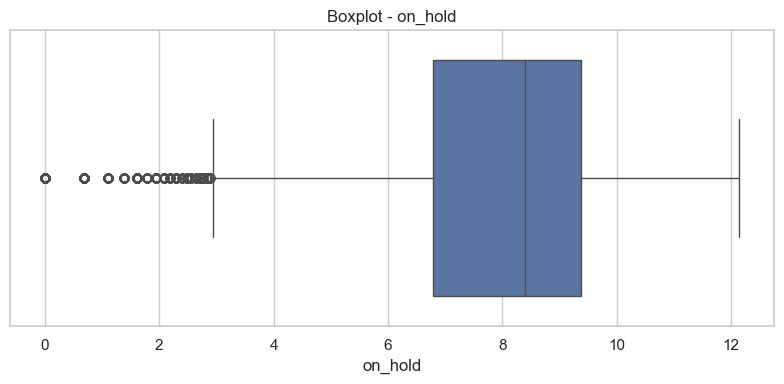

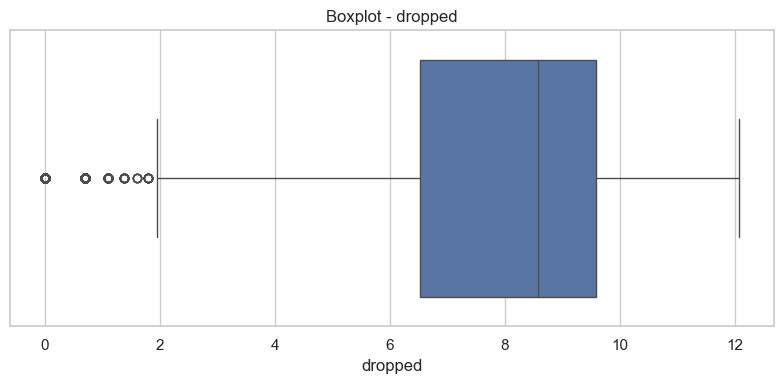

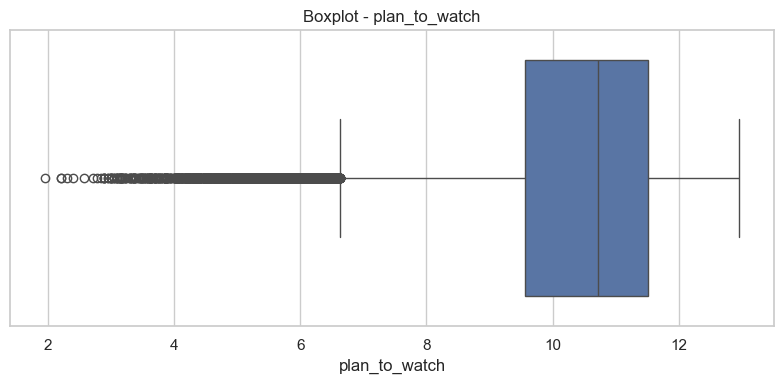

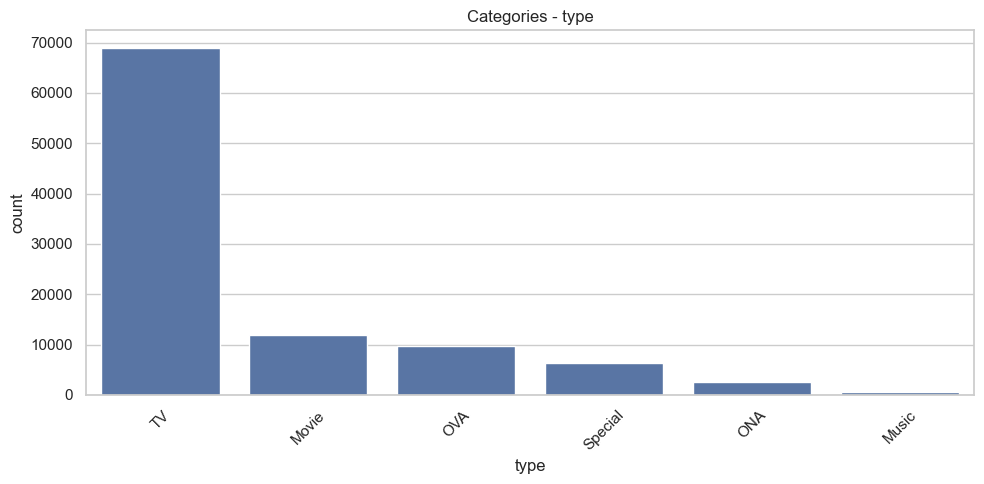

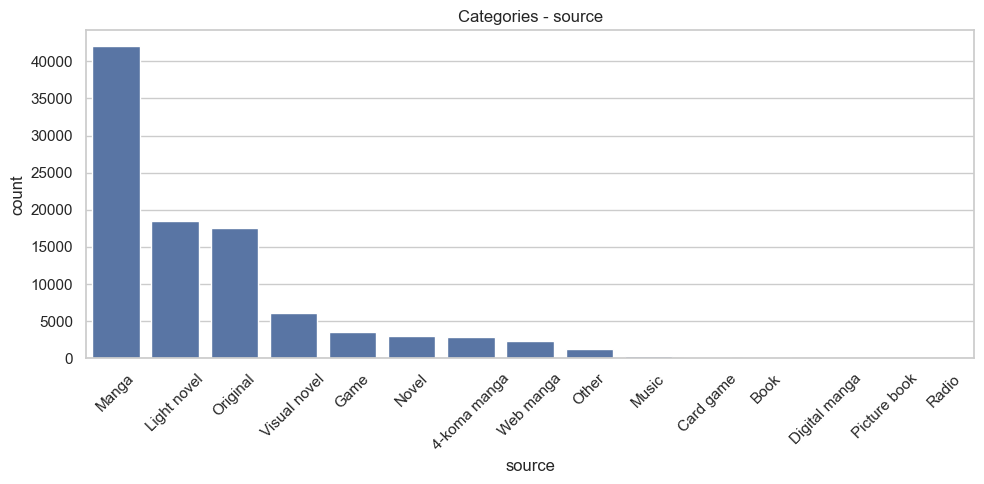

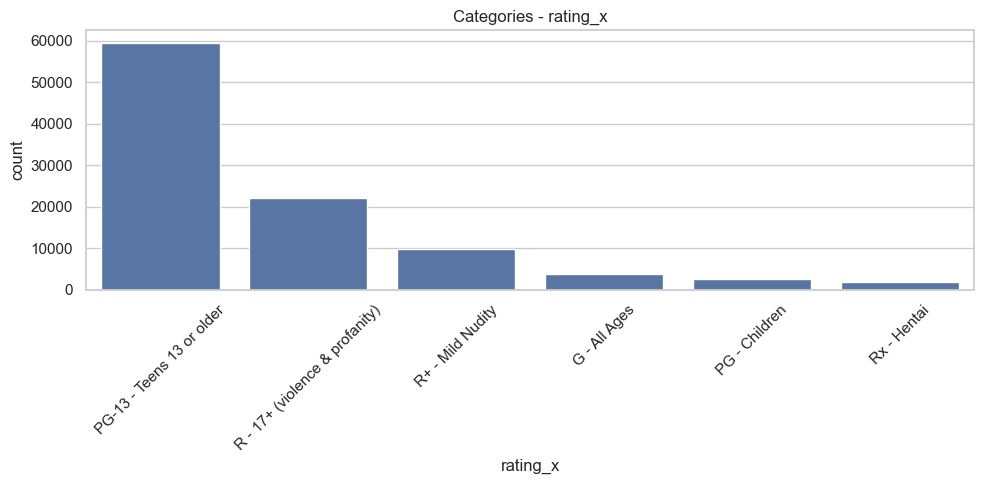

In [19]:
def plot_dataframe(df):
    # Numeric columns
    numeric_cols = numeric_analysis_cols
    # Categorical columns
    categorical_cols = categorical_analysis_cols

    # ---------- BOXPLOTS ----------
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        
        sns.boxplot(x=df[col])
        
        plt.title(f"Boxplot - {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

    # ---------- HISTOGRAMS / COUNTPLOTS ----------
    for col in categorical_cols:
        plt.figure(figsize=(10, 5))
        
        order = df[col].value_counts().index
        
        sns.countplot(
            data=df,
            x=col,
            order=order
        )
        
        plt.title(f"Categories - {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
plot_dataframe(df_log.to_pandas())

In [20]:
from scipy.stats import shapiro

for col in numeric_analysis_cols:
    stat, p_value = shapiro(df[col].dropna())

    print(f'Column: {col}')
    print(f'Shapiro-Wilk Statistic: {stat:.5f}')
    print(f'p-value: {p_value:.5f}')

    if p_value > 0.05:
        print('Probably normal distribution')
    else:
        print('Probably NOT normal distribution')

    print('-' * 40)

AttributeError: 'Series' object has no attribute 'dropna'